# 02 — Modeling Results, Error Analysis, and Interpretation

This notebook consolidates the forecasting results generated by the training scripts.

The goals are to:
- compare baseline performance against the machine learning model,
- evaluate the contribution of the predefined feature blocks,
- inspect permutation importance for the best tuned configuration,
- analyze prediction error behavior,
- and summarize the key modeling findings in a concise, presentation-ready format.

## Why this notebook matters

The assessment explicitly asks for model evaluation, advanced analyses, feature-importance techniques, geographical/environmental analysis, and a well-organized report or presentation. This notebook is therefore designed to act as the **results layer** of the project rather than a raw experimentation log. fileciteturn9file0

In addition, permutation importance is used here because scikit-learn documents it as a model-agnostic inspection method computed from the degradation in model performance after shuffling a feature, and notes that it avoids important limitations of impurity-based tree importances on held-out data. citeturn723882search0turn723882search2turn723882search9

## 1. Load model outputs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")

baseline_results = pd.read_csv("../reports/baseline_metrics.csv")
ml_results = pd.read_csv("../reports/ml_results.csv")
importance_df = pd.read_csv("../reports/ml_feature_importance.csv")
ml_predictions = pd.read_parquet("../reports/ml_predictions.parquet")

baseline_results = baseline_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
ml_results = ml_results.sort_values(["mae", "rmse"]).reset_index(drop=True)
importance_df = importance_df.sort_values("importance_mean", ascending=False).reset_index(drop=True)

baseline_results.head(), ml_results.head(), importance_df.head()

(              model       mae      rmse        r2       mape
 0  last_observation  1.851315  2.725922  0.940315  55.886455
 1    rolling_mean_3  2.153061  3.120490  0.921786  69.991565
 2       naive_lag_1  2.297220  3.362395  0.909189  72.557792
 3       naive_lag_2  2.475494  3.602066  0.895782  80.603152
 4       naive_lag_3  2.548230  3.702112  0.889913  80.783772,
                         feature_set  n_features                        model  \
 0  C_temporal_meteorology_geography          29  RandomForestRegressor_tuned   
 1  C_temporal_meteorology_geography          29        RandomForestRegressor   
 2            B_temporal_meteorology          27        RandomForestRegressor   
 3                            D_full          37        RandomForestRegressor   
 4                   A_temporal_core          18        RandomForestRegressor   
 
         mae      rmse        r2       mape  \
 0  1.743873  2.528803  0.948608  56.549117   
 1  1.754461  2.553303  0.947607  55.453987  

## 2. Executive summary table

Instead of showing all outputs immediately, start with the three most important comparisons:
1. the best baseline,
2. the best untuned machine learning model,
3. the best tuned machine learning model.

This gives the evaluator a fast, executive view of whether the supervised approach actually added value.

In [2]:
best_baseline = baseline_results.iloc[0].copy()
best_untuned_ml = ml_results[ml_results["model"] == "RandomForestRegressor"].sort_values(["mae", "rmse"]).iloc[0].copy()
best_tuned_ml = ml_results[ml_results["model"] == "RandomForestRegressor_tuned"].sort_values(["mae", "rmse"]).iloc[0].copy()

summary_df = pd.DataFrame([
    {
        "approach": "Best baseline",
        "configuration": best_baseline["model"],
        "mae": best_baseline["mae"],
        "rmse": best_baseline["rmse"],
        "r2": best_baseline["r2"],
        "mape": best_baseline["mape"],
    },
    {
        "approach": "Best ML (untuned)",
        "configuration": f'{best_untuned_ml["model"]} | {best_untuned_ml["feature_set"]}',
        "mae": best_untuned_ml["mae"],
        "rmse": best_untuned_ml["rmse"],
        "r2": best_untuned_ml["r2"],
        "mape": best_untuned_ml["mape"],
    },
    {
        "approach": "Best ML (tuned)",
        "configuration": f'{best_tuned_ml["model"]} | {best_tuned_ml["feature_set"]}',
        "mae": best_tuned_ml["mae"],
        "rmse": best_tuned_ml["rmse"],
        "r2": best_tuned_ml["r2"],
        "mape": best_tuned_ml["mape"],
    },
])

summary_df

,approach,configuration,mae,rmse,r2,mape
0,Best baseline,last_observation,1.851315,2.725922,0.940315,55.886455
1,Best ML (untuned),RandomForestRegressor | C_temporal_meteorology...,1.754461,2.553303,0.947607,55.453987
2,Best ML (tuned),RandomForestRegressor_tuned | C_temporal_meteo...,1.743873,2.528803,0.948608,56.549117


In [3]:
mae_gain_abs = best_baseline["mae"] - best_tuned_ml["mae"]
mae_gain_pct = mae_gain_abs / best_baseline["mae"] * 100
rmse_gain_abs = best_baseline["rmse"] - best_tuned_ml["rmse"]
r2_gain_abs = best_tuned_ml["r2"] - best_baseline["r2"]

summary_text = f'''
### Initial finding

The strongest baseline was **{best_baseline["model"]}** with **MAE = {best_baseline["mae"]:.3f}** and **R² = {best_baseline["r2"]:.3f}**.  
The best final model was **{best_tuned_ml["model"]}** using **{best_tuned_ml["feature_set"]}**, reaching **MAE = {best_tuned_ml["mae"]:.3f}**, **RMSE = {best_tuned_ml["rmse"]:.3f}**, and **R² = {best_tuned_ml["r2"]:.3f}**.  

Relative to the strongest baseline, the tuned model improved MAE by **{mae_gain_abs:.3f} °C** (**{mae_gain_pct:.2f}%**) and improved RMSE by **{rmse_gain_abs:.3f} °C**.  
This indicates that the machine learning pipeline added predictive value beyond simple persistence.
'''
display(Markdown(summary_text))


### Initial finding

The strongest baseline was **last_observation** with **MAE = 1.851** and **R² = 0.940**.  
The best final model was **RandomForestRegressor_tuned** using **C_temporal_meteorology_geography**, reaching **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**.  

Relative to the strongest baseline, the tuned model improved MAE by **0.107 °C** (**5.80%**) and improved RMSE by **0.197 °C**.  
This indicates that the machine learning pipeline added predictive value beyond simple persistence.


## 3. Baseline performance

In [4]:
baseline_results

,model,mae,rmse,r2,mape
0,last_observation,1.851315,2.725922,0.940315,55.886455
1,rolling_mean_3,2.153061,3.120490,0.921786,69.991565
2,naive_lag_1,2.297220,3.362395,0.909189,72.557792
3,naive_lag_2,2.475494,3.602066,0.895782,80.603152
4,naive_lag_3,2.548230,3.702112,0.889913,80.783772


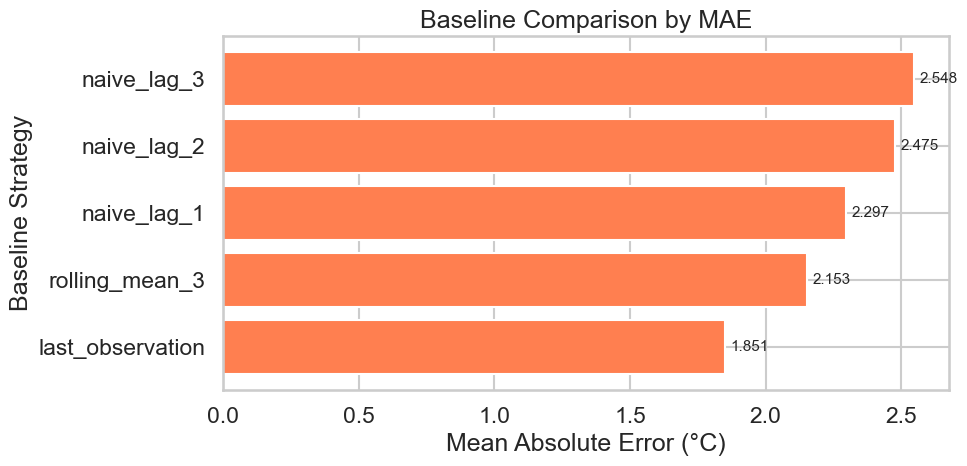

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
baseline_plot = baseline_results.sort_values("mae", ascending=True)

ax.barh(baseline_plot["model"], baseline_plot["mae"], color="coral")
ax.set_title("Baseline Comparison by MAE")
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Baseline Strategy")

for i, v in enumerate(baseline_plot["mae"]):
    ax.text(v + 0.02, i, f"{v:.3f}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

### Interpretation

The baseline section establishes the minimum performance threshold that a more complex model must beat to justify its added complexity.  
Here, the `last_observation` baseline is notably stronger than the lag-only alternatives, which suggests strong short-term persistence in the temperature series.

## 4. Machine learning comparison across feature blocks

In [6]:
ml_results

,feature_set,n_features,model,mae,rmse,r2,mape,best_params
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl..."
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN


## Model comparison

This section compares the machine learning configurations using MAE and RMSE.  
The objective is to determine whether adding meteorological, geographic, and environmental predictors improves performance beyond the temporal core, and whether hyperparameter tuning provides additional value.

In [32]:
comparison_plot = ml_results.copy()

label_map = {
    "A_temporal_core": "A | Temporal core",
    "B_temporal_meteorology": "B | Temporal + meteorology",
    "C_temporal_meteorology_geography": "C | Temporal + meteorology + geography",
    "D_full": "D | Full feature set",
}

comparison_plot["feature_label"] = comparison_plot["feature_set"].map(label_map)
comparison_plot["model_label"] = comparison_plot["model"].replace(
    {
        "RandomForestRegressor": "Random Forest",
        "RandomForestRegressor_tuned": "Random Forest (tuned)",
    }
)

comparison_plot["label"] = comparison_plot["feature_label"] + " | " + comparison_plot["model_label"]
comparison_plot

,feature_set,n_features,model,mae,rmse,r2,mape,best_params,feature_label,model_label,label
0,C_temporal_meteorology_geography,29,RandomForestRegressor_tuned,1.743873,2.528803,0.948608,56.549117,"{'model__n_estimators': 250, 'model__min_sampl...",C | Temporal + meteorology + geography,Random Forest (tuned),C | Temporal + meteorology + geography | Rando...
1,C_temporal_meteorology_geography,29,RandomForestRegressor,1.754461,2.553303,0.947607,55.453987,NaN,C | Temporal + meteorology + geography,Random Forest,C | Temporal + meteorology + geography | Rando...
2,B_temporal_meteorology,27,RandomForestRegressor,1.757000,2.566012,0.947085,55.289049,NaN,B | Temporal + meteorology,Random Forest,B | Temporal + meteorology | Random Forest
3,D_full,37,RandomForestRegressor,1.759364,2.569779,0.946929,55.047383,NaN,D | Full feature set,Random Forest,D | Full feature set | Random Forest
4,A_temporal_core,18,RandomForestRegressor,1.799388,2.633394,0.944269,54.870132,NaN,A | Temporal core,Random Forest,A | Temporal core | Random Forest


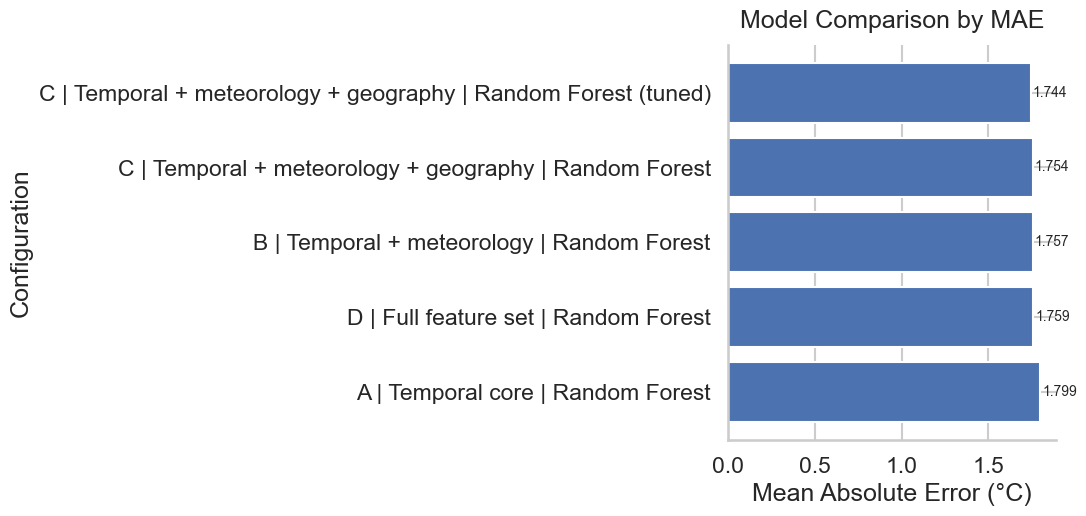

In [33]:
plot_mae = comparison_plot.sort_values("mae", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_mae["label"], plot_mae["mae"])

ax.set_title("Model Comparison by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

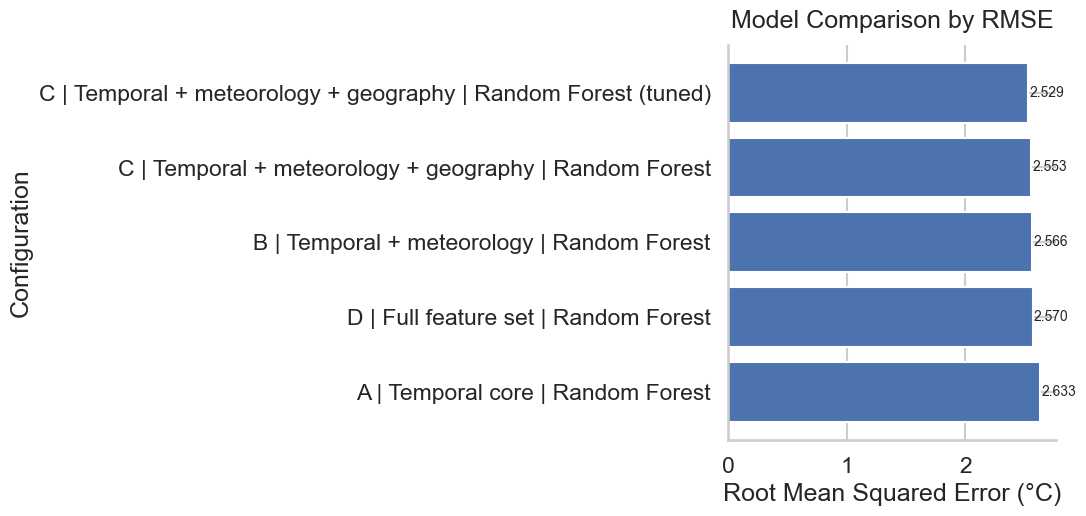

In [37]:
plot_rmse = comparison_plot.sort_values("rmse", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.barh(plot_rmse["label"], plot_rmse["rmse"])

ax.set_title("Model Comparison by RMSE", pad=12)
ax.set_xlabel("Root Mean Squared Error (°C)")
ax.set_ylabel("Configuration")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [35]:
best_baseline = baseline_results.sort_values("mae", ascending=True).iloc[0].copy()
best_ml = ml_results.sort_values("mae", ascending=True).iloc[0].copy()

summary_df = pd.DataFrame(
    [
        {
            "configuration": "Best baseline",
            "mae": best_baseline["mae"],
            "rmse": best_baseline["rmse"],
            "r2": best_baseline["r2"],
        },
        {
            "configuration": "Best ML model",
            "mae": best_ml["mae"],
            "rmse": best_ml["rmse"],
            "r2": best_ml["r2"],
        },
    ]
)

summary_df

,configuration,mae,rmse,r2
0,Best baseline,1.851315,2.725922,0.940315
1,Best ML model,1.743873,2.528803,0.948608


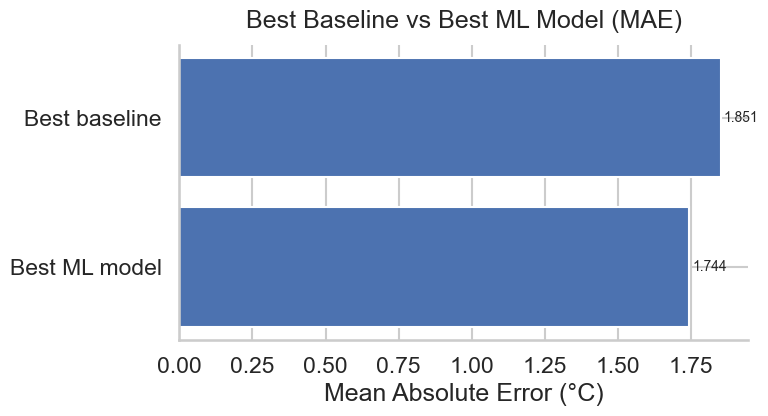

In [36]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(summary_df["configuration"], summary_df["mae"])

ax.set_title("Best Baseline vs Best ML Model (MAE)", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=10,
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [38]:
feature_block_results = ml_results[ml_results["model"] == "RandomForestRegressor"].sort_values("mae").reset_index(drop=True)

block_summary = f'''
### Initial finding

Among the untuned feature blocks, **{feature_block_results.iloc[0]["feature_set"]}** achieved the best performance with **MAE = {feature_block_results.iloc[0]["mae"]:.3f}**.  
The ranking suggests that adding **meteorological** and **geographic** context improved performance relative to the temporal-only block, while the **full** configuration with air-quality variables did not outperform the best intermediate setup.
'''
display(Markdown(block_summary))


### Initial finding

Among the untuned feature blocks, **C_temporal_meteorology_geography** achieved the best performance with **MAE = 1.754**.  
The ranking suggests that adding **meteorological** and **geographic** context improved performance relative to the temporal-only block, while the **full** configuration with air-quality variables did not outperform the best intermediate setup.


## 5. Permutation importance of the best tuned model

The purpose of this section is not to claim causality.  
Instead, it identifies which variables the **final fitted model** relied on most when making predictions on the held-out test set.

In [9]:
top_importance = importance_df.head(15).copy()
top_importance

,feature,importance_mean,importance_std,feature_set
0,temperature_celsius,3.836215,0.014983,C_temporal_meteorology_geography
1,feels_like_celsius,2.855105,0.022283,C_temporal_meteorology_geography
2,temp_roll_mean_3,0.514289,0.007060,C_temporal_meteorology_geography
3,temp_lag_3,0.074038,0.002052,C_temporal_meteorology_geography
4,latitude,0.062531,0.002296,C_temporal_meteorology_geography
5,temp_lag_1,0.037366,0.001722,C_temporal_meteorology_geography
6,temp_lag_2,0.036211,0.001528,C_temporal_meteorology_geography
7,pressure_mb,0.025009,0.001399,C_temporal_meteorology_geography
8,humidity,0.012265,0.000720,C_temporal_meteorology_geography
9,uv_index,0.004964,0.000521,C_temporal_meteorology_geography


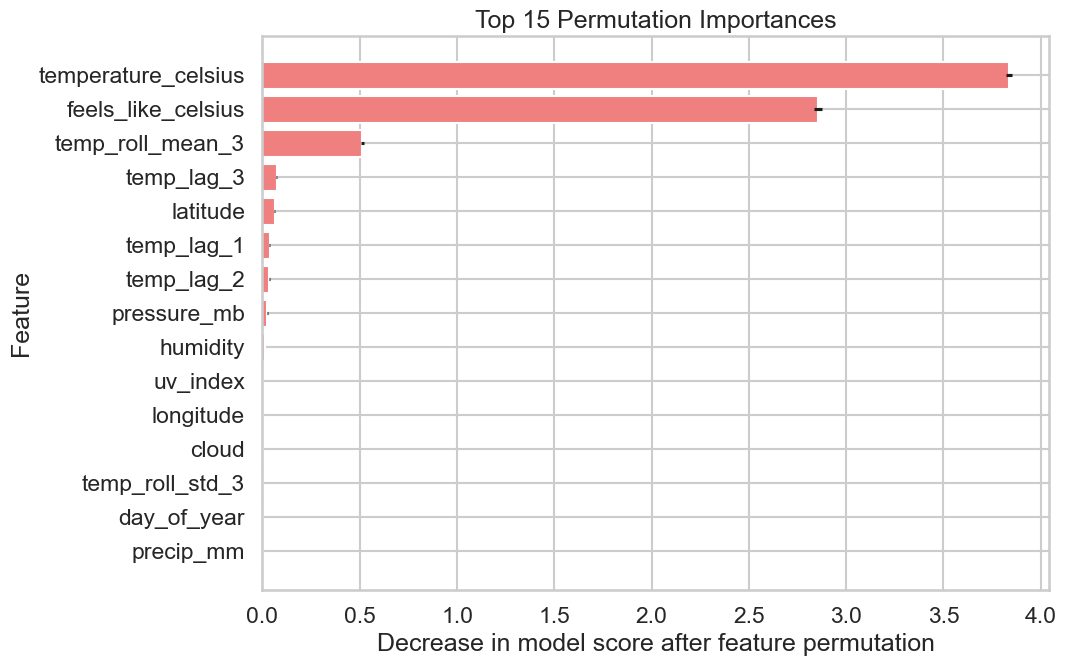

In [22]:
top_importance_plot = top_importance.sort_values("importance_mean", ascending=True)

fig, ax = plt.subplots(figsize=(11, 7))
ax.barh(
    top_importance_plot["feature"],
    top_importance_plot["importance_mean"],
    xerr=top_importance_plot["importance_std"],
    color="lightcoral",
)
ax.set_title("Top 15 Permutation Importances")
ax.set_xlabel("Decrease in model score after feature permutation")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

In [11]:
top3 = importance_df.head(3)["feature"].tolist()
imp_text = f'''
### Initial finding

The importance analysis shows a clear hierarchy. The top contributors were **{top3[0]}**, **{top3[1]}**, and **{top3[2]}**.  
This supports the earlier correlation analysis: short-term prediction is driven mainly by recent thermal information, with additional gains from contextual variables rather than from the full environmental block.
'''
display(Markdown(imp_text))


### Initial finding

The importance analysis shows a clear hierarchy. The top contributors were **temperature_celsius**, **feels_like_celsius**, and **temp_roll_mean_3**.  
This supports the earlier correlation analysis: short-term prediction is driven mainly by recent thermal information, with additional gains from contextual variables rather than from the full environmental block.


## 6. Prediction error analysis for the best final model

In [12]:
best_feature_set = best_tuned_ml["feature_set"]
best_preds = ml_predictions[ml_predictions["feature_set"] == best_feature_set].copy()

best_preds["error"] = best_preds["target_temperature_next"] - best_preds["prediction"]
best_preds["absolute_error"] = best_preds["error"].abs()

best_preds.head()

,location_name,country,last_updated,target_temperature_next,feature_set,prediction,error,absolute_error
52134,Madrid,Spain,2025-11-04 08:45:00,12.3,C_temporal_meteorology_geography,9.021127,3.278873,3.278873
52135,Warsaw,Poland,2025-11-04 09:00:00,6.1,C_temporal_meteorology_geography,8.048903,-1.948903,1.948903
52136,'S-Gravenbrakel,Belgium,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,10.653892,1.646108,1.646108
52137,Andorra La Vella,Andorra,2025-11-04 09:00:00,5.5,C_temporal_meteorology_geography,6.791142,-1.291142,1.291142
52138,Amsterdam,Netherlands,2025-11-04 09:00:00,12.3,C_temporal_meteorology_geography,11.174860,1.125140,1.125140


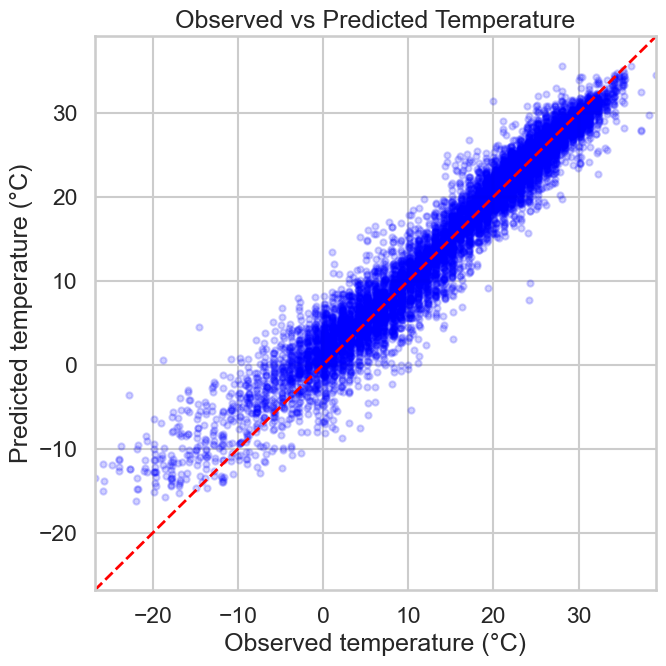

In [17]:
sample_n = min(len(best_preds), 12000)
plot_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

obs_min = min(plot_sample["target_temperature_next"].min(), plot_sample["prediction"].min())
obs_max = max(plot_sample["target_temperature_next"].max(), plot_sample["prediction"].max())

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_sample["target_temperature_next"], plot_sample["prediction"], c="blue", alpha=0.18, s=20)
ax.plot([obs_min, obs_max], [obs_min, obs_max], linestyle="--", c="red", linewidth=2)
ax.set_title("Observed vs Predicted Temperature")
ax.set_xlabel("Observed temperature (°C)")
ax.set_ylabel("Predicted temperature (°C)")
ax.set_xlim(obs_min, obs_max)
ax.set_ylim(obs_min, obs_max)
plt.tight_layout()
plt.show()

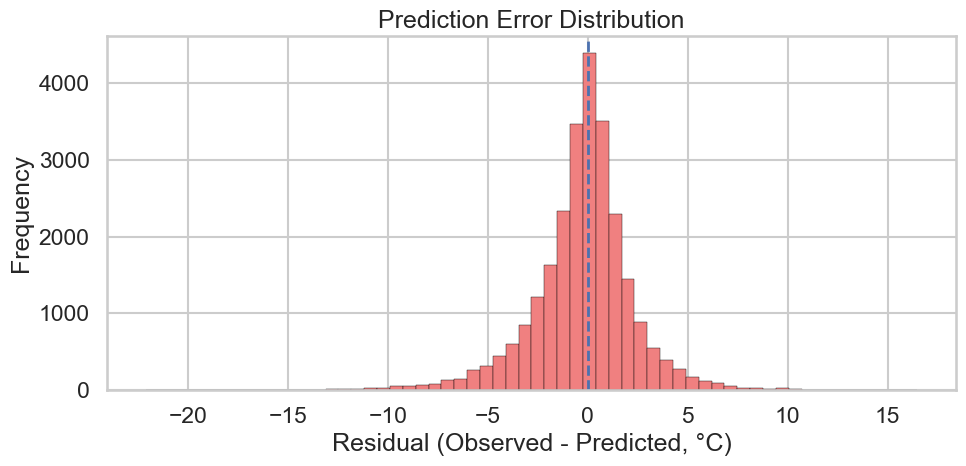

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(best_preds["error"], bins=60, edgecolor="black", color="lightcoral",linewidth=0.3)
ax.axvline(0, linestyle="--", linewidth=2)
ax.set_title("Prediction Error Distribution")
ax.set_xlabel("Residual (Observed - Predicted, °C)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

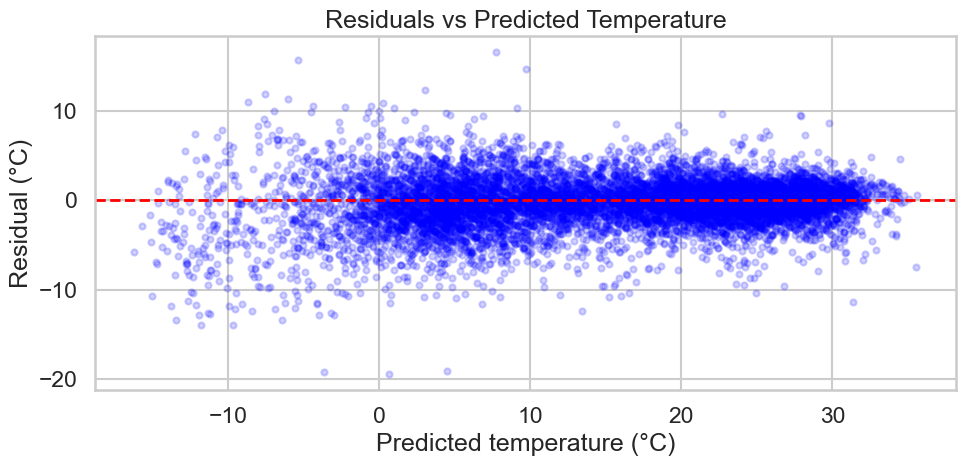

In [27]:
sample_n = min(len(best_preds), 12000)
resid_sample = best_preds.sample(sample_n, random_state=42) if len(best_preds) > sample_n else best_preds.copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(resid_sample["prediction"], resid_sample["error"], c="blue", alpha=0.18, s=20)
ax.axhline(0, linestyle="--", c="red", linewidth=2)
ax.set_title("Residuals vs Predicted Temperature")
ax.set_xlabel("Predicted temperature (°C)")
ax.set_ylabel("Residual (°C)")
plt.tight_layout()
plt.show()

In [31]:
best_preds["absolute_error"] = best_preds["error"].abs()

error_summary = (
    best_preds["absolute_error"]
    .describe(percentiles=[0.5, 0.9, 0.95])
    [["mean", "50%", "90%", "95%", "max"]]
    .rename(
        {
            "mean": "mean_abs_error",
            "50%": "median_abs_error",
            "90%": "p90_abs_error",
            "95%": "p95_abs_error",
            "max": "max_abs_error",
        }
    )
)

error_summary.to_frame(name="value")

,value
mean_abs_error,1.754461
median_abs_error,1.171201
p90_abs_error,4.065878
p95_abs_error,5.416794
max_abs_error,22.134074


## 7. Optional extension: where does the model struggle most?

The assessment encourages advanced and differentiated analyses. A useful next step is to inspect whether error varies by geography or local conditions rather than stopping at global averages. fileciteturn9file0

In [29]:
city_error = (
    best_preds.groupby(["country", "location_name"], as_index=False)
    .agg(
        n_obs=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda x: np.sqrt(np.mean(np.square(x)))),
    )
    .sort_values(["mae", "rmse"], ascending=[False, False])
)

city_error.head(15)

,country,location_name,n_obs,mae,rmse
145,Russia,Chi-Chi-Erh,32,7.342283,9.136284
173,Switzerland,S-Chanf,16,5.249603,5.932012
91,Kazakhstan,Astana,134,4.899215,6.485592
34,Canada,Ottawa,134,4.521040,5.661357
8,Australia,Canberra,134,4.221791,5.182182
15,Belarus,Minsk,133,4.024579,5.353998
129,Norway,Oslo,133,3.824818,5.052745
61,Finland,Helsinki,134,3.727471,4.792805
116,Mongolia,Ulaanbaatar,135,3.713931,4.983483
101,Lithuania,Vilnius,134,3.336975,4.375031


## 8. Final interpretation

Use the text below as the final narrative block of the notebook, adjusting only if later experiments materially change the metrics.

In [30]:
final_text = f'''
### Final interpretation

The strongest baseline was **{best_baseline["model"]}**, confirming that short-term weather forecasting in this dataset has strong temporal persistence.  
Even so, the final tuned Random Forest model improved on that baseline and achieved the best overall performance with **MAE = {best_tuned_ml["mae"]:.3f}**, **RMSE = {best_tuned_ml["rmse"]:.3f}**, and **R² = {best_tuned_ml["r2"]:.3f}**.

Across the predefined feature blocks, the best untuned configuration was **{best_untuned_ml["feature_set"]}**, indicating that **temporal + meteorological + geographic** information offered the best balance between predictive signal and model complexity.  
The full feature block, including air-quality variables, did not outperform this intermediate setup, suggesting that those variables added limited marginal value for this specific next-step temperature task.

Permutation importance showed that the model relied primarily on **temperature_celsius**, **feels_like_celsius**, and **temp_roll_mean_3**, which is consistent with the earlier audit and correlation analysis.  
Overall, the results indicate that recent thermal history is the main driver of predictive performance, while selected meteorological and geographic features provide incremental improvements.

A key limitation is that the current task is still a **next-step** forecasting problem rather than a strictly controlled next-day benchmark, and therefore future work should test longer horizons, broader model families, and geographically disaggregated error analysis.
'''
display(Markdown(final_text))


### Final interpretation

The strongest baseline was **last_observation**, confirming that short-term weather forecasting in this dataset has strong temporal persistence.  
Even so, the final tuned Random Forest model improved on that baseline and achieved the best overall performance with **MAE = 1.744**, **RMSE = 2.529**, and **R² = 0.949**.

Across the predefined feature blocks, the best untuned configuration was **C_temporal_meteorology_geography**, indicating that **temporal + meteorological + geographic** information offered the best balance between predictive signal and model complexity.  
The full feature block, including air-quality variables, did not outperform this intermediate setup, suggesting that those variables added limited marginal value for this specific next-step temperature task.

Permutation importance showed that the model relied primarily on **temperature_celsius**, **feels_like_celsius**, and **temp_roll_mean_3**, which is consistent with the earlier audit and correlation analysis.  
Overall, the results indicate that recent thermal history is the main driver of predictive performance, while selected meteorological and geographic features provide incremental improvements.

A key limitation is that the current task is still a **next-step** forecasting problem rather than a strictly controlled next-day benchmark, and therefore future work should test longer horizons, broader model families, and geographically disaggregated error analysis.


## Error analysis by location

Average model performance can hide important local differences.  
This section evaluates prediction error at the city level to identify locations where the model performs consistently well and locations where forecasting remains more difficult.

In [40]:
location_error_df = (
    best_preds.groupby(["location_name", "country"], as_index=False)
    .agg(
        n_predictions=("absolute_error", "size"),
        mae=("absolute_error", "mean"),
        rmse=("error", lambda s: (s.pow(2).mean()) ** 0.5),
        mean_error=("error", "mean"),
    )
    .sort_values("mae", ascending=True)
)

location_error_df.head(10)

,location_name,country,n_predictions,mae,rmse,mean_error
157,Roseau,Dominica,132,0.253764,0.309782,0.069408
57,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
178,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
95,Lima,Peru,133,0.430026,0.538831,0.084135
198,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
114,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
116,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
59,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
136,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
35,Bras,Brazil,133,0.615540,0.843967,-0.029507


In [41]:
top_best_locations = location_error_df[location_error_df["n_predictions"] >= 30].sort_values("mae").head(10)
top_best_locations

,location_name,country,n_predictions,mae,rmse,mean_error
157,Roseau,Dominica,132,0.253764,0.309782,0.069408
57,Dhidhdhoo,Maldives,134,0.327640,0.431170,-0.156751
178,Tarawa,Kiribati,135,0.374909,0.465156,0.104746
95,Lima,Peru,133,0.430026,0.538831,0.084135
198,Yamoussoukro,Cote d'Ivoire,133,0.487544,0.695401,-0.161539
114,Mogadishu,Somalia,133,0.497065,0.648485,0.107582
116,Monrovia,Liberia,133,0.500299,0.713449,-0.012175
59,Djibouti,Djibouti,134,0.500831,0.632262,-0.091487
136,Paramaribo,Suriname,132,0.577143,0.792130,-0.113206
35,Bras,Brazil,133,0.615540,0.843967,-0.029507


In [42]:
top_worst_locations = location_error_df[location_error_df["n_predictions"] >= 30].sort_values("mae", ascending=False).head(10)
top_worst_locations

,location_name,country,n_predictions,mae,rmse,mean_error
50,Chi-Chi-Erh,Russia,32,7.342283,9.136284,-6.836793
15,Astana,Kazakhstan,134,4.899215,6.485592,-2.614771
132,Ottawa,Canada,134,4.521040,5.661357,-1.650700
45,Canberra,Australia,134,4.221791,5.182182,0.967932
113,Minsk,Belarus,133,4.024579,5.353998,-2.336509
131,Oslo,Norway,133,3.824818,5.052745,-0.674156
74,Helsinki,Finland,134,3.727471,4.792805,-1.614812
187,Ulaanbaatar,Mongolia,135,3.713931,4.983483,-2.977160
193,Vilnius,Lithuania,134,3.336975,4.375031,-1.680944
119,Moscow,Russia,134,3.328761,4.547924,-2.077207


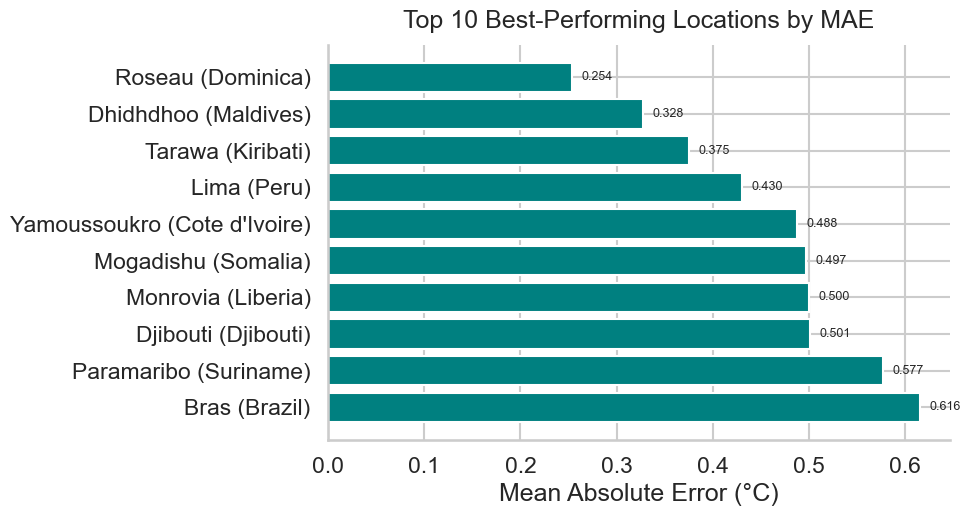

In [50]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    top_best_locations["location_name"] + " (" + top_best_locations["country"] + ")",
    top_best_locations["mae"],
    color= "teal",
)

ax.set_title("Top 10 Best-Performing Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

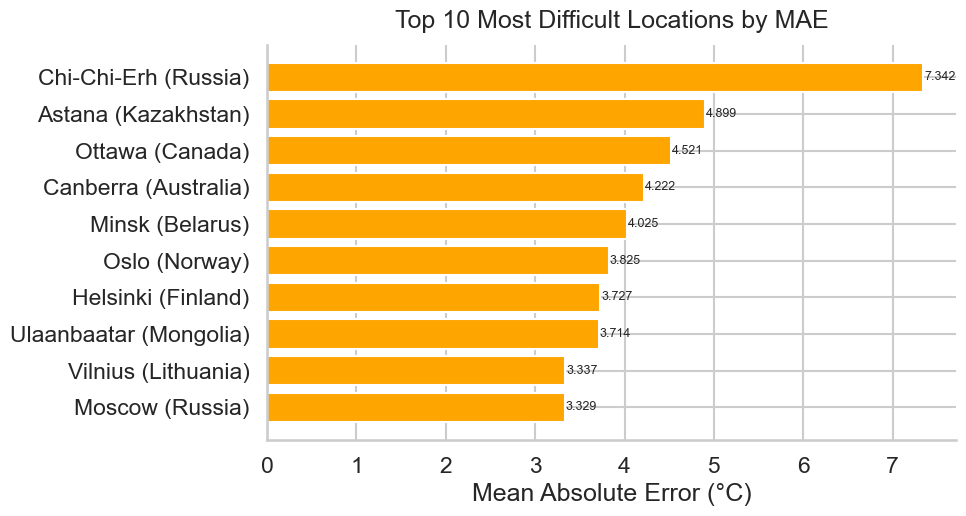

In [55]:
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(
    top_worst_locations["location_name"] + " (" + top_worst_locations["country"] + ")",
    top_worst_locations["mae"],
    color="orange"

)

ax.set_title("Top 10 Most Difficult Locations by MAE", pad=12)
ax.set_xlabel("Mean Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.01, bar.get_y() + bar.get_height() / 2, f"{width:.3f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Initial finding

The city-level error analysis shows that forecasting quality is not uniform across locations.  
Some cities exhibit consistently low error, while others remain more challenging, likely due to stronger variability, local weather dynamics, or reduced regularity in recent temperature patterns.

## Extreme errors and difficult cases

Beyond average performance, it is important to inspect the largest prediction errors.  
This helps identify failure modes, understand whether the model struggles with abrupt changes, and define realistic limitations of the forecasting pipeline.

In [58]:
hard_cases = best_preds.copy().sort_values("absolute_error", ascending=False)
hard_cases.head(15)

,location_name,country,last_updated,target_temperature_next,feature_set,prediction,error,absolute_error
61407,Chi-Chi-Erh,Russia,2025-12-21 14:00:00,-14.0,C_temporal_meteorology_geography,8.134074,-22.134074,22.134074
61991,Chi-Chi-Erh,Russia,2025-12-24 14:00:00,-18.8,C_temporal_meteorology_geography,0.640889,-19.440889,19.440889
62175,Astana,Kazakhstan,2025-12-25 12:00:00,-22.8,C_temporal_meteorology_geography,-3.629125,-19.170875,19.170875
58858,Astana,Kazakhstan,2025-12-08 12:15:00,-18.9,C_temporal_meteorology_geography,0.254217,-19.154217,19.154217
64659,Bogot,Bulgaria,2026-01-07 09:15:00,-14.6,C_temporal_meteorology_geography,4.482285,-19.082285,19.082285
61798,Chi-Chi-Erh,Russia,2025-12-23 14:15:00,-14.8,C_temporal_meteorology_geography,3.822559,-18.622559,18.622559
57935,Ottawa,Canada,2025-12-04 02:00:00,-21.0,C_temporal_meteorology_geography,-3.218307,-17.781693,17.781693
73182,Oslo,Norway,2026-02-21 07:45:00,-13.9,C_temporal_meteorology_geography,3.767760,-17.667760,17.667760
72491,Ashgabat,Turkmenistan,2026-02-17 11:45:00,24.2,C_temporal_meteorology_geography,7.707705,16.492295,16.492295
76137,Astana,Kazakhstan,2026-03-08 11:45:00,-15.9,C_temporal_meteorology_geography,0.017263,-15.917263,15.917263


In [59]:
hard_cases[
    [
        "location_name",
        "country",
        "last_updated",
        "target_temperature_next",
        "prediction",
        "error",
        "absolute_error",
    ]
].head(15)

,location_name,country,last_updated,target_temperature_next,prediction,error,absolute_error
61407,Chi-Chi-Erh,Russia,2025-12-21 14:00:00,-14.0,8.134074,-22.134074,22.134074
61991,Chi-Chi-Erh,Russia,2025-12-24 14:00:00,-18.8,0.640889,-19.440889,19.440889
62175,Astana,Kazakhstan,2025-12-25 12:00:00,-22.8,-3.629125,-19.170875,19.170875
58858,Astana,Kazakhstan,2025-12-08 12:15:00,-18.9,0.254217,-19.154217,19.154217
64659,Bogot,Bulgaria,2026-01-07 09:15:00,-14.6,4.482285,-19.082285,19.082285
61798,Chi-Chi-Erh,Russia,2025-12-23 14:15:00,-14.8,3.822559,-18.622559,18.622559
57935,Ottawa,Canada,2025-12-04 02:00:00,-21.0,-3.218307,-17.781693,17.781693
73182,Oslo,Norway,2026-02-21 07:45:00,-13.9,3.767760,-17.667760,17.667760
72491,Ashgabat,Turkmenistan,2026-02-17 11:45:00,24.2,7.707705,16.492295,16.492295
76137,Astana,Kazakhstan,2026-03-08 11:45:00,-15.9,0.017263,-15.917263,15.917263


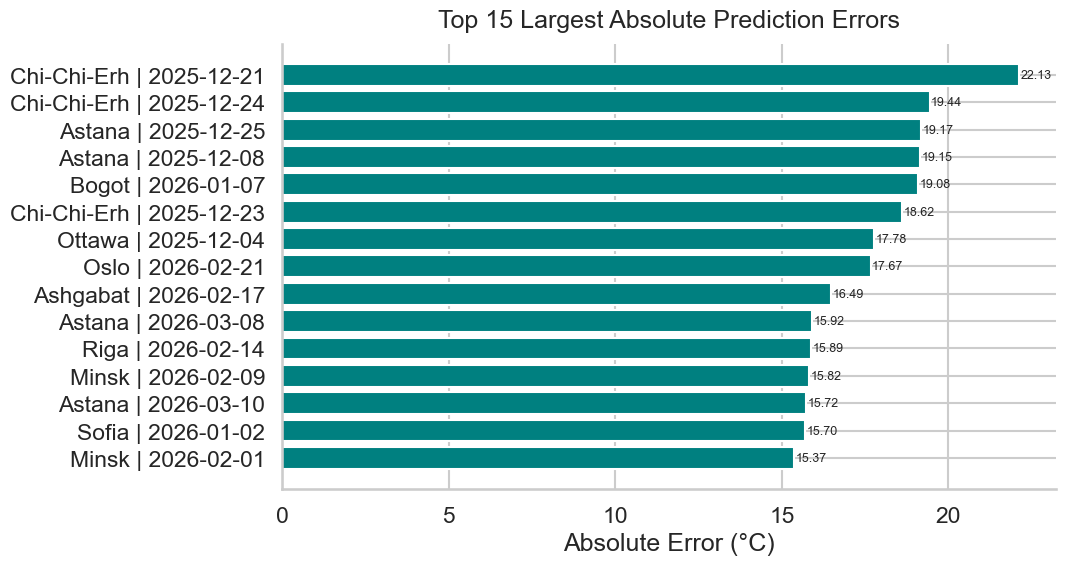

In [62]:
top_hard_cases = hard_cases.head(15).copy()
top_hard_cases["label"] = (
    top_hard_cases["location_name"]
    + " | "
    + top_hard_cases["last_updated"].astype(str).str[:10]
)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_hard_cases["label"], top_hard_cases["absolute_error"], color="teal")

ax.set_title("Top 15 Largest Absolute Prediction Errors", pad=12)
ax.set_xlabel("Absolute Error (°C)")
ax.set_ylabel("")
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.05, bar.get_y() + bar.get_height() / 2, f"{width:.2f}", va="center", fontsize=9)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

In [65]:
best_preds = best_preds.copy()
best_preds["temp_change"] = best_preds["target_temperature_next"] - best_preds["temperature_proxy"]

KeyError: 'temperature_proxy'